<a href="https://colab.research.google.com/github/ichika-yay/Economics-Brawl-Stars/blob/main/%E9%82%8A%E9%9A%9B%E6%95%88%E7%94%A8%E7%90%86%E8%AB%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
print("=====蔓蒂糖果店開張=====")
bonnie_coin = int(input("請輸入駛徒給了邦妮多少金幣 "))
candy_price = int(input("請輸入糖果的價格 "))
cookie_price = int(input("請輸入餅乾的價格 "))
print(f"邦妮的金幣有{bonnie_coin}個")
print(f"糖果售價{candy_price}元")
print(f"餅乾售價{cookie_price}元")

=====蔓蒂糖果店開張=====
請輸入駛徒給了邦妮多少金幣 10
請輸入糖果的價格 2
請輸入餅乾的價格 1
邦妮的金幣有10個
糖果售價2元
餅乾售價1元


In [ ]:
def bonnie_u(candy,cookie):
 candy_u = 1.5 * np.log(candy+1)
 cookie_u = 1.0 * np.log(cookie+1)
 return candy_u + cookie_u
print(f"糖果0顆 餅乾0塊:{bonnie_u(0,0):.2f}分")
print(f"糖果1顆 餅乾1塊:{bonnie_u(1,1):.2f}分")
print(f"糖果2顆 餅乾2塊:{bonnie_u(2,2):.2f}分")
print(f"糖果3顆 餅乾3塊:{bonnie_u(3,3):.2f}分")

糖果0顆 餅乾0塊:0.00分
糖果1顆 餅乾1塊:1.73分
糖果2顆 餅乾2塊:2.75分
糖果3顆 餅乾3塊:3.47分


In [ ]:
candy_c = int(input("邦妮買了多少顆糖(暫不考慮預算)"))
cookie_c = int(input("邦妮買了多少塊餅乾(暫不考慮預算)"))
print(f"邦妮獲得的效用值為{bonnie_u(candy_c,cookie_c):.2f}分")

邦妮買了多少顆糖(暫不考慮預算)5
邦妮買了多少塊餅乾(暫不考慮預算)5
邦妮獲得的效用值為4.48分


In [ ]:
from scipy.optimize import minimize
def utility(choices):
  candy,cookie = choices
  return -bonnie_u(candy,cookie)
def budget(choices):
  candy,cookie = choices
  spent = (candy * candy_price) + (cookie * cookie_price)
  return bonnie_coin - spent
con = ({'type':'eq','fun':budget})
bounds = ((0,None),(0,None))
initial_guess = [1,1]
result = minimize(utility,initial_guess,bounds=bounds,constraints=con)
best_candy,best_cookie = result.x
candy_mu = 1.5 / (best_candy+1)
cookie_mu = 1.0 / (best_cookie+1)
candy_mu_price = candy_mu / candy_price
cookie_mu_price = cookie_mu / cookie_price
print("=====邦妮的黃金消費均衡組合=====")
print(f"邦妮應該買{best_candy:.2f}顆糖果")
print(f"邦妮應該買{best_cookie:.2f}塊餅乾")
print(f"邦妮總共花了{candy_price*best_candy+cookie_price*best_cookie:.2f}元")
print(f"邦妮獲得的效用值為{-result.fun:.4f}分")
print("================================")
print("驗證最後1元的邊際效用是否相等?")
print(f"邦妮花在糖果上的最後1元效用值為{candy_mu_price:.4f}分")
print(f"邦妮花在餅乾上的最後1元效用值為{cookie_mu_price:.4f}分")


=====邦妮的黃金消費均衡組合=====
邦妮應該買2.90顆糖果
邦妮應該買4.20塊餅乾
邦妮總共花了10.00元
邦妮獲得的效用值為3.6901分
驗證最後1元的邊際效用是否相等?
邦妮花在糖果上的最後1元效用值為0.1923分
邦妮花在餅乾上的最後1元效用值為0.1923分


In [ ]:
max_u = -1
rbest_candy = 0
rbest_cookie = 0
max_candy = bonnie_coin // candy_price
for candy in range(max_candy + 1):
  remain_coin = bonnie_coin - (candy * candy_price)
  max_cookie = remain_coin // cookie_price
  for cookie in range(max_cookie + 1):
    total_cost = (candy * candy_price) + (cookie * cookie_price)
    if total_cost <= bonnie_coin:
      cur_u = bonnie_u(candy,cookie)
      if cur_u > max_u:
        max_u = cur_u
        rbest_candy = candy
        rbest_cookie = cookie
print("=====邦妮在現實中的黃金消費組合=====")
print(f"邦妮應該買{rbest_candy}顆糖果")
print(f"邦妮應該買{rbest_cookie}塊餅乾")
print(f"邦妮總共花了{rbest_candy*candy_price+rbest_cookie*cookie_price}元")
print(f"邦妮獲得的效用值為{max_u:.4f}分")

=====邦妮在現實中的黃金消費組合=====
邦妮應該買3顆糖果
邦妮應該買4塊餅乾
邦妮總共花了10元
邦妮獲得的效用值為3.6889分


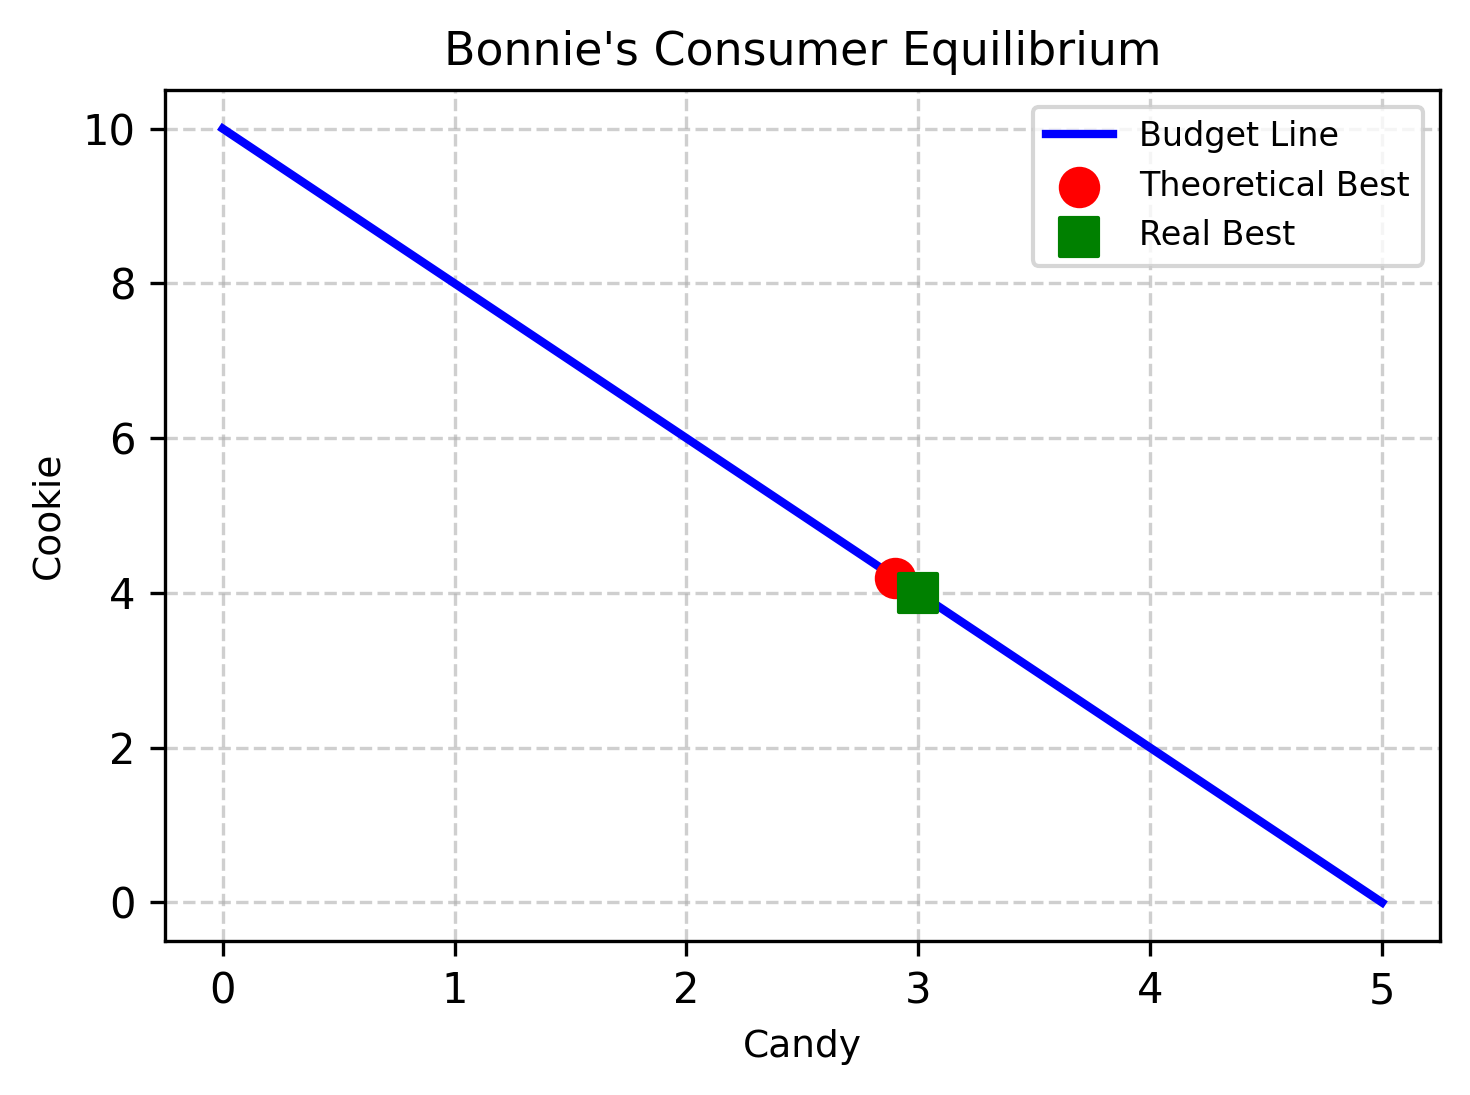

In [ ]:
import matplotlib.pyplot as plt
candy_axis = np.linspace(0,bonnie_coin/candy_price,100)
cookie_axis = (bonnie_coin-candy_axis*candy_price)/cookie_price
plt.figure(figsize=(5,3.75),dpi=300,facecolor="white")
plt.plot(candy_axis,cookie_axis,label="Budget Line",linewidth=2,color="blue")
plt.scatter(best_candy,best_cookie,color="red",label="Theoretical Best",s=80,zorder=5)
plt.scatter(rbest_candy,rbest_cookie,color="green",label="Real Best",s=80,zorder=5,marker="s")
plt.title("Bonnie\'s Consumer Equilibrium",fontsize=11)
plt.xlabel("Candy",fontsize=9)
plt.ylabel("Cookie",fontsize=9)
plt.grid(True,linestyle="--",alpha=0.6)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()